# Analisis Dataset Heart Disease

## Melakukan Import

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Membaca CSV Dataset

In [11]:
data  = pd.read_csv("heart_disease_dataset.csv")
label = data["target"]
display(data.describe())
display(data.info())
display(data.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Mengidentifikasi Nilai NaN

In [3]:
nan_mask = data.isna()

cols_with_nan = nan_mask.any(axis=0)
cols_with_nan = cols_with_nan[cols_with_nan == True]
if len(cols_with_nan) == 0:
    print("No column with missing or NaN values, therefore no rows with NaN values.")
else:
    print("Columns with NaN values:")
    print(cols_with_nan.values)
    
    print()
    print("Rows with NaN values:")
    display(data.loc[nan_mask.any(axis=1)])

No column with missing or NaN values, therefore no rows with NaN values.


## Mengecek Distribusi Setiap Kolom

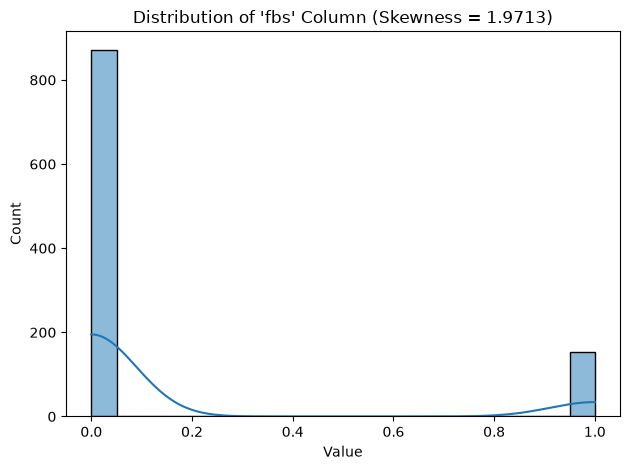

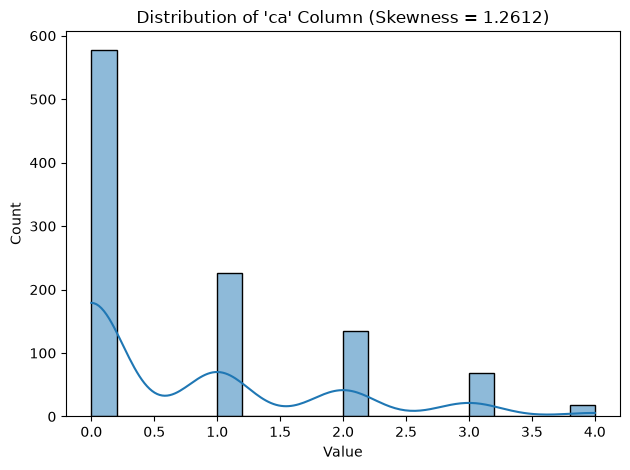

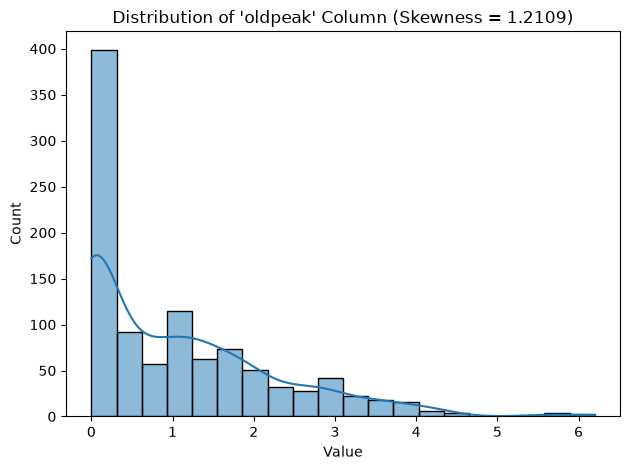

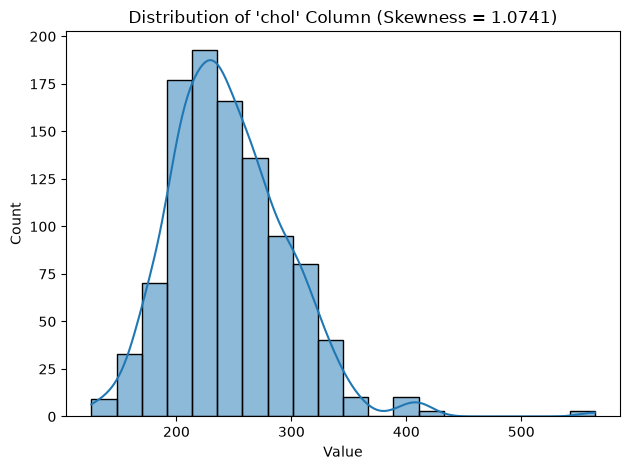

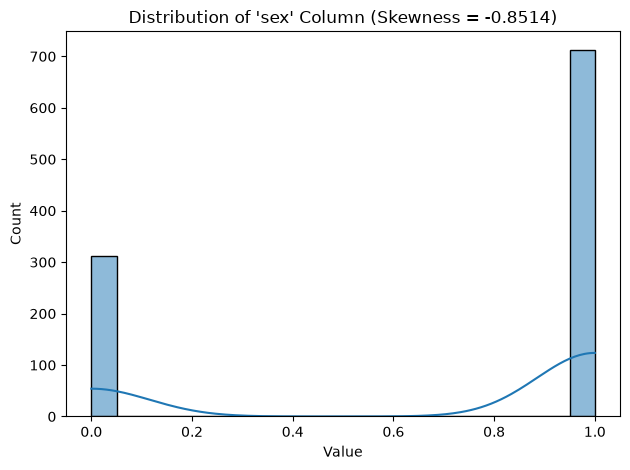

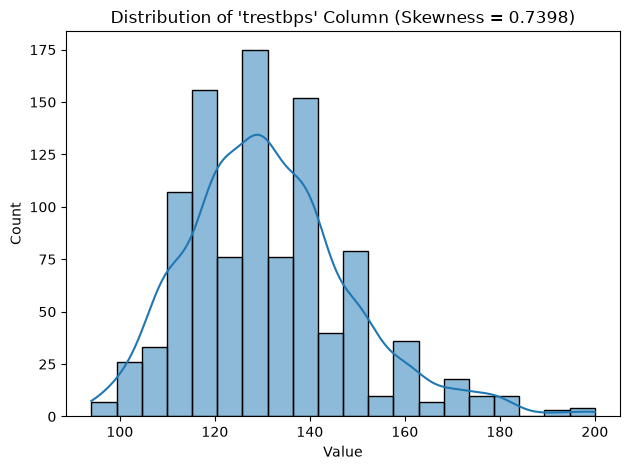

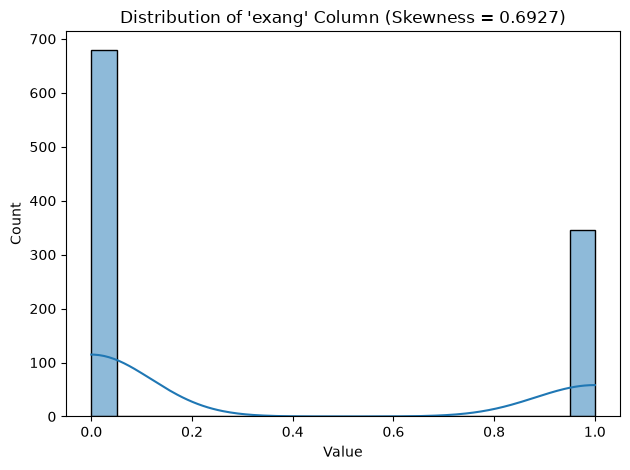

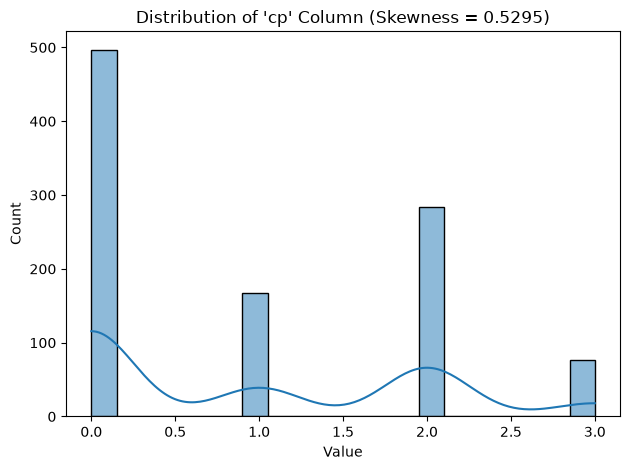

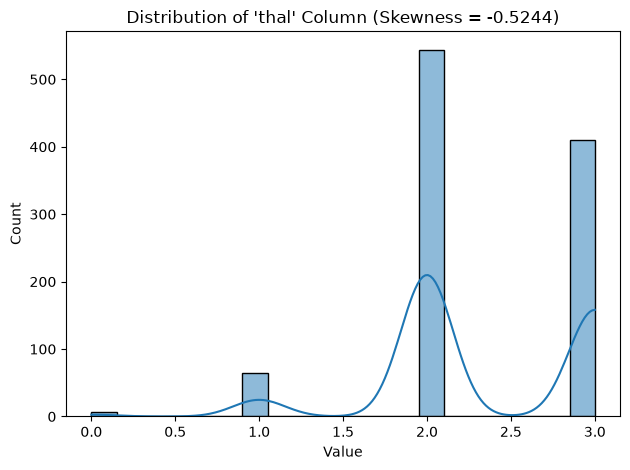

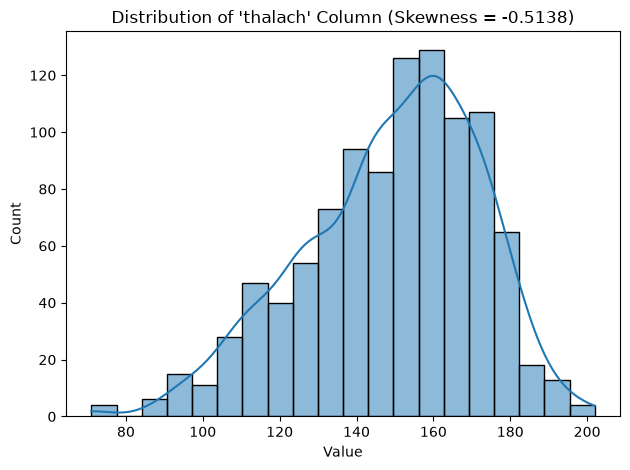

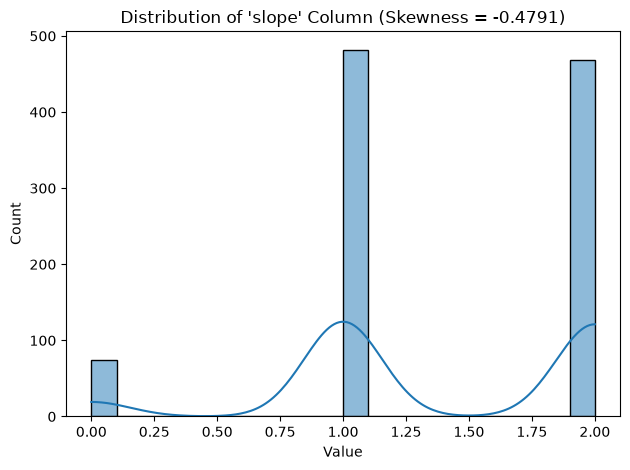

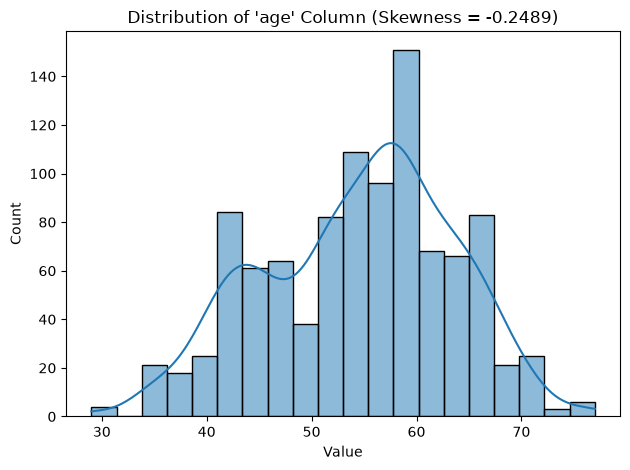

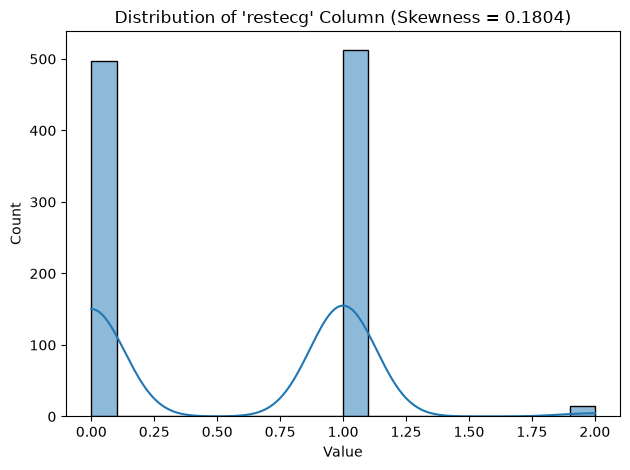

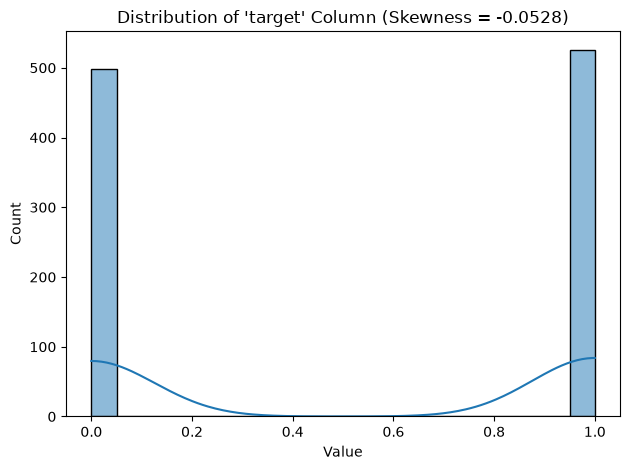

In [17]:
nrows, ncols  = 4, 4
skewness_data = data.skew().sort_values(key=lambda x: abs(x), ascending=False)

# fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(40, 36))
for i, col in enumerate(skewness_data.index):
    col_data = data[col].value_counts().sort_index()
    skew_val = skewness_data[col]
    
    sns.histplot(x=col, data=data, bins=20, kde=True, )
    plt.title(f"Distribution of '{col}' Column (Skewness = {skew_val:.4f})")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## Memvisualisasikan Relasi antar Fitur Menggunakan Pairplot

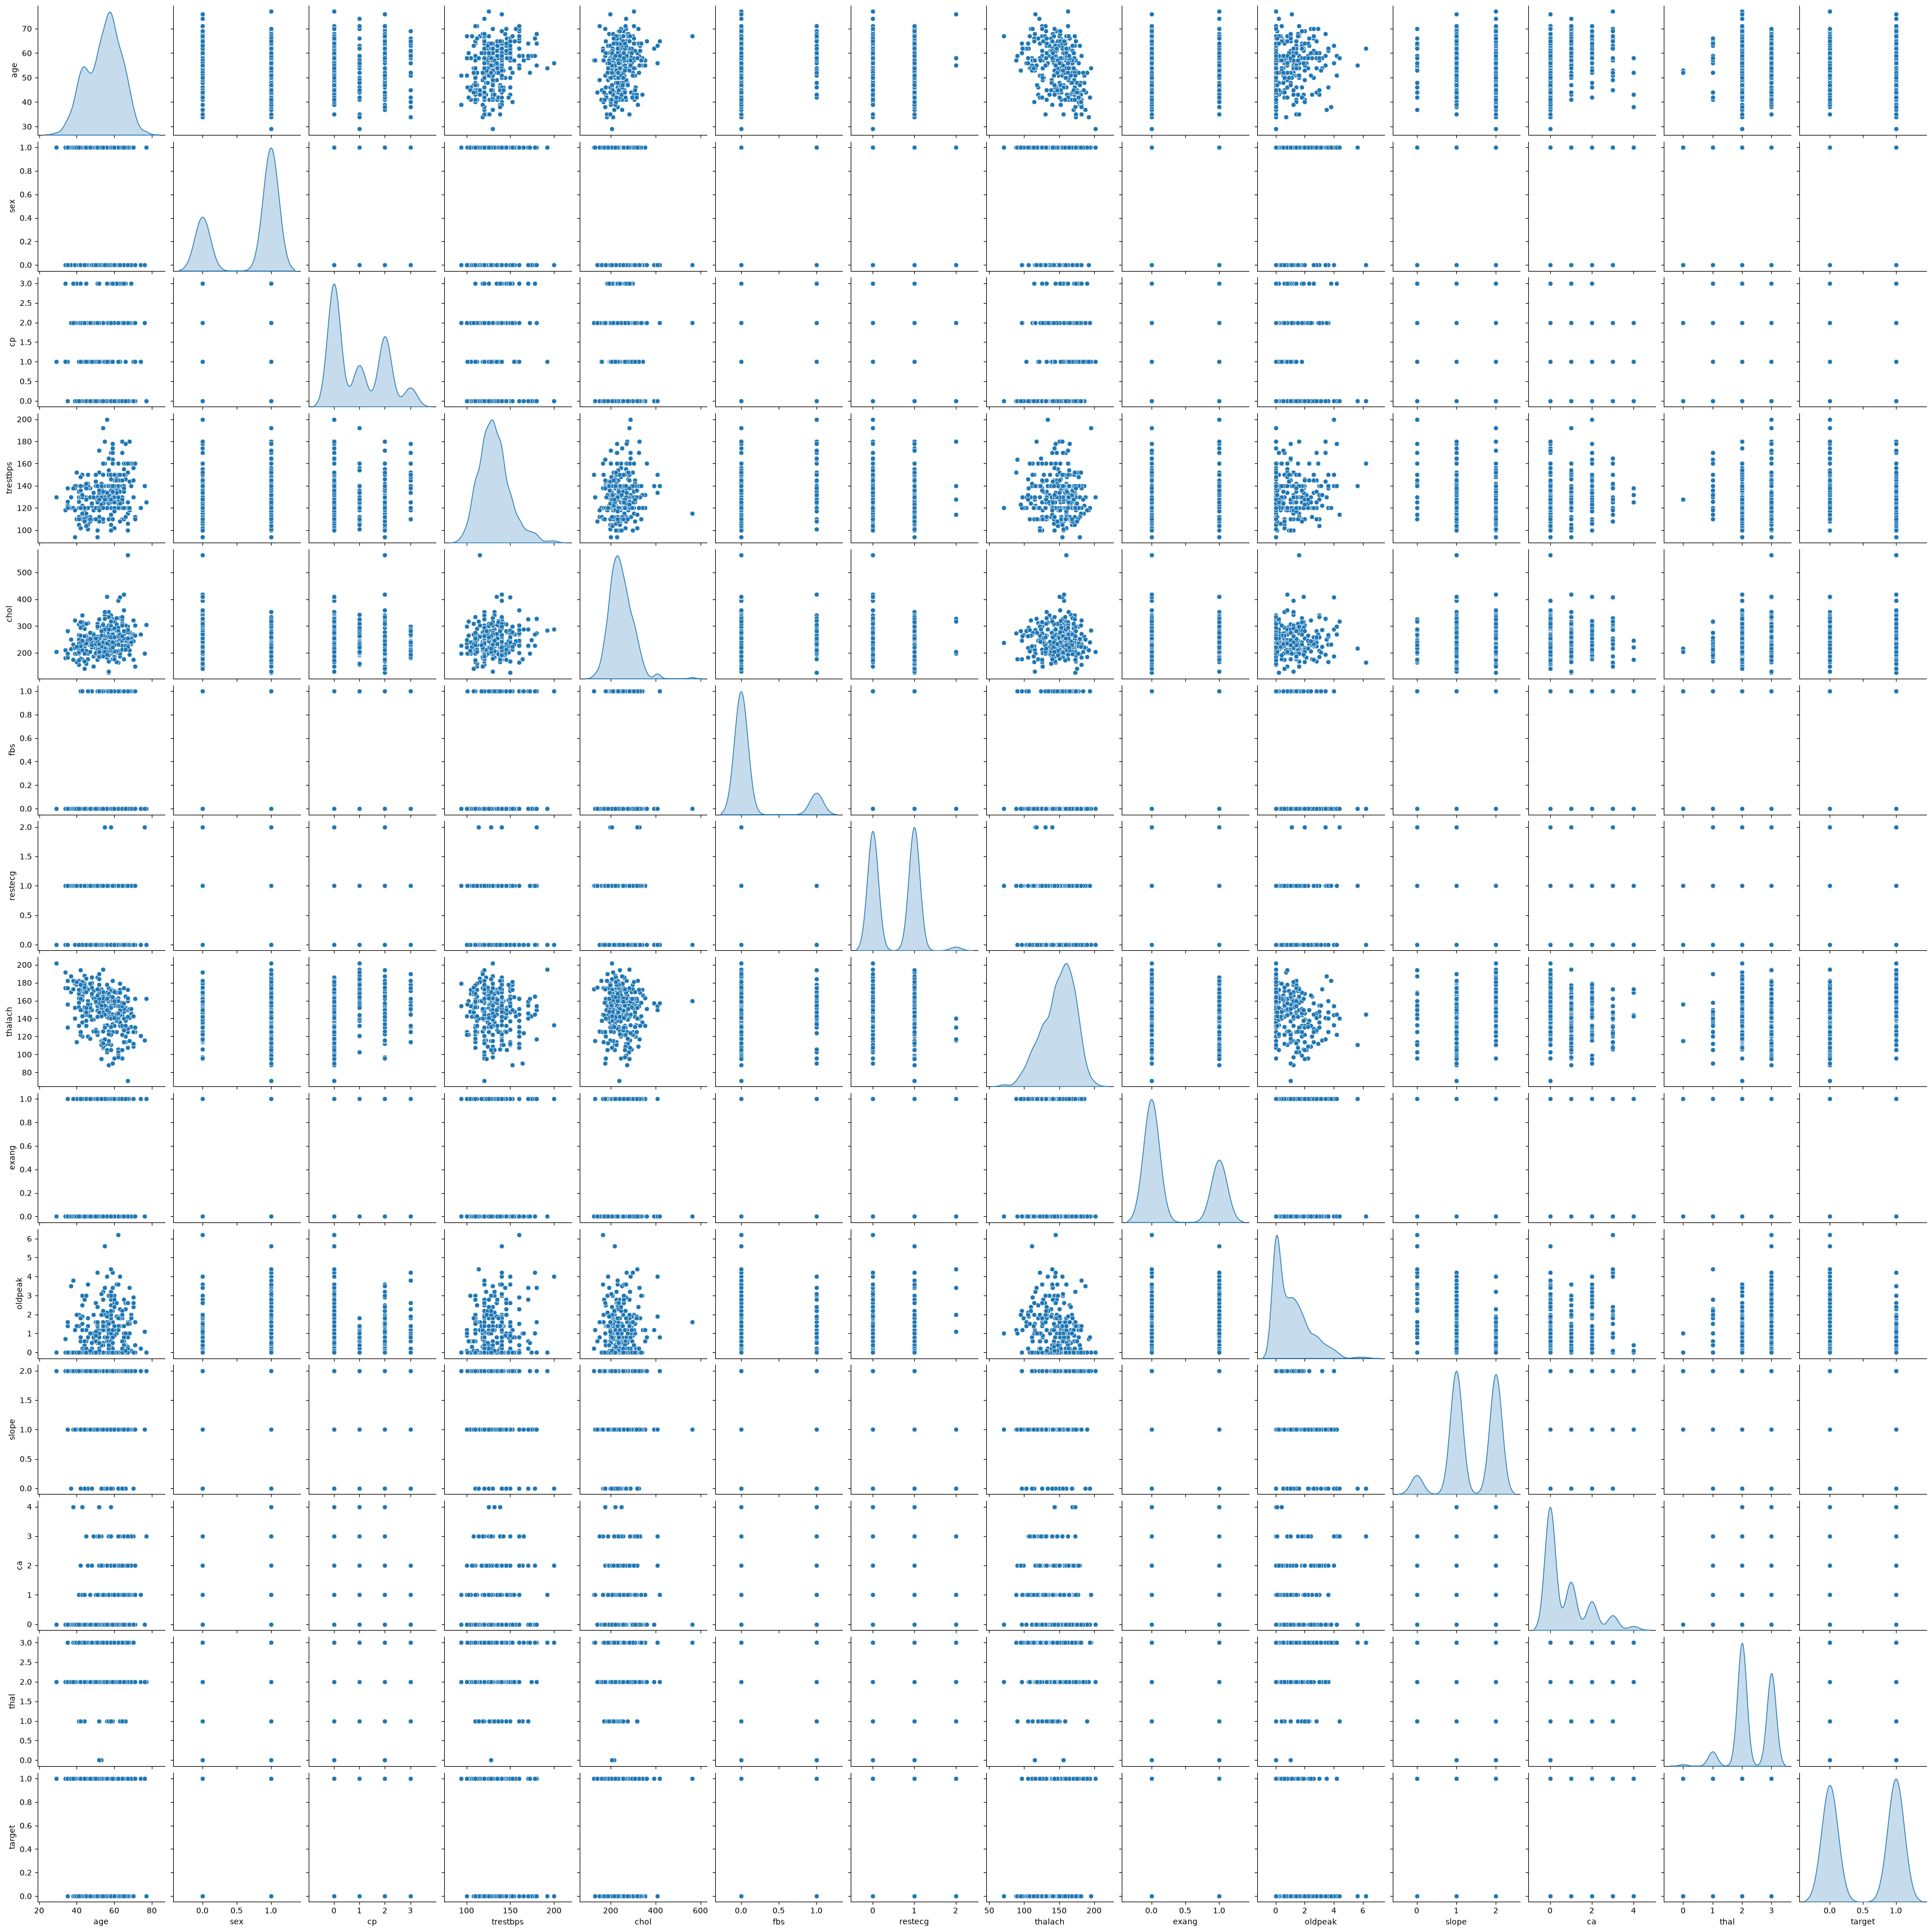

In [5]:
axs = sns.pairplot(data, diag_kind="kde")
plt.show()

## Mendapatkan Matriks Korelasi

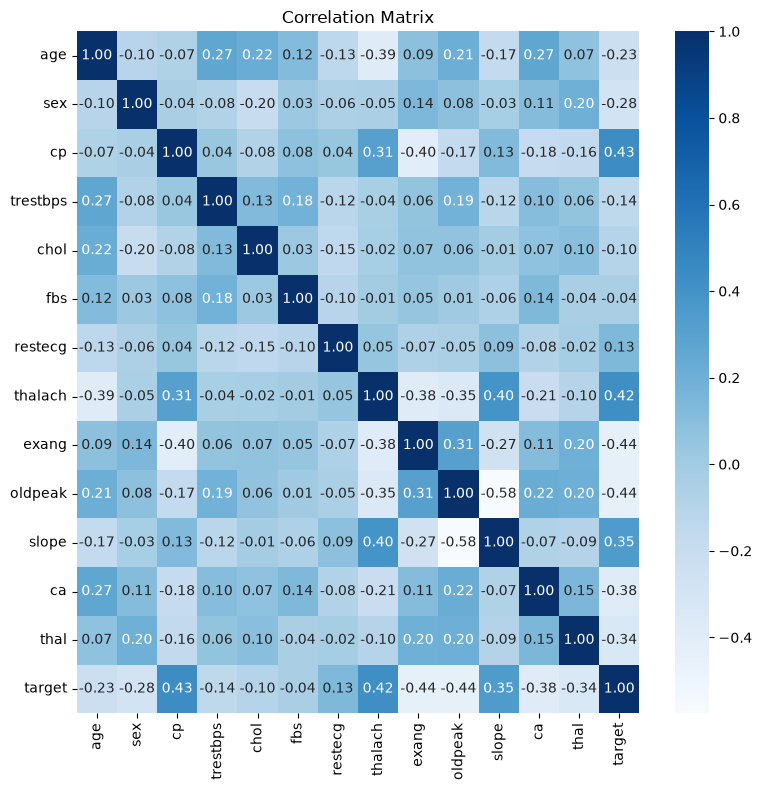

In [6]:
corr_data = data.corr()

axs = sns.heatmap(corr_data, annot=True, cmap="Blues", fmt=".2f")
axs.figure.set_size_inches(8, 8)
axs.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Mengurutkan Korelasi dari Yang Paling Besar

In [7]:
sorted_coor_data = dict()

for row in corr_data.index:
    for col in corr_data.columns:
        if row != col and f"{col} - {row}" not in sorted_coor_data.keys():
            sorted_coor_data[f"{row} - {col}"] = corr_data[col][row]
            
sorted_coor_data = sorted(sorted_coor_data.items(), key=lambda x: abs(x[1]), reverse=True)

top_corr_num = 10
top_corr_data = sorted_coor_data[:top_corr_num]
print(f"Top {top_corr_num} correlation(s) with the high the highest correlation score (ignoring the negative relationship):")
for i, (var_corr, corr_score) in enumerate(top_corr_data):
    print(f"{i+1}. {var_corr}: {corr_score}")

Top 10 correlation(s) with the high the highest correlation score (ignoring the negative relationship):
1. oldpeak - slope: -0.575188536437517
2. oldpeak - target: -0.4384412701119449
3. exang - target: -0.438028550055846
4. cp - target: 0.434854250052737
5. thalach - target: 0.4228954964828723
6. cp - exang: -0.40151271399953703
7. thalach - slope: 0.395307843482417
8. age - thalach: -0.3902270750315936
9. ca - target: -0.3820852890386709
10. thalach - exang: -0.38028087239195574


## Mendapatkan Matriks Kovarians

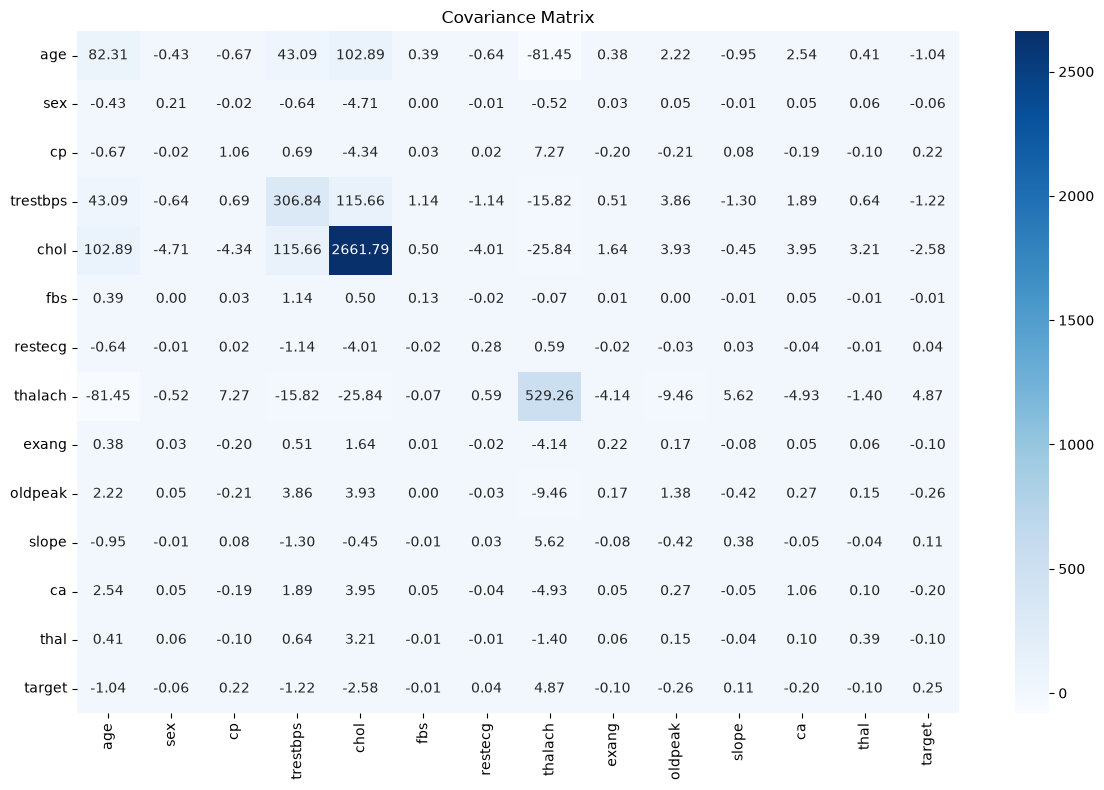

In [8]:
cov_data = data.cov()

axs = sns.heatmap(cov_data, annot=True, cmap="Blues", fmt=".2f")
axs.figure.set_size_inches(12, 8)
axs.set_title("Covariance Matrix")
plt.tight_layout()
plt.show()

## Mencari Fitur yang Memiliki Koefisien Korelasi Pearson Tinggi terhadap Status Diabetes

In [9]:
target_corr_data = [item for item in sorted_coor_data if "target" in item[0]]
rename_corr_data = [[item[0].replace("target", "").replace("-", "").replace(" ", ""), item[1]] for item in target_corr_data]

sorted_target_corr_data = sorted(rename_corr_data, key=lambda x: abs(x[1]), reverse=True)
series_corr_data        = pd.DataFrame(
    data=[item[1] for item in sorted_target_corr_data],
    index=[item[0] for item in sorted_target_corr_data],
    columns=["Coefficient"]
)
display(series_corr_data)

,Coefficient
oldpeak,-0.438441
exang,-0.438029
cp,0.434854
thalach,0.422895
ca,-0.382085
slope,0.345512
thal,-0.337838
sex,-0.279501
age,-0.229324
trestbps,-0.138772
